In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/q2_customers.csv')
df.head()



,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)


Scaling is important in K-Means because it uses distance. If features are on different scales, the model will be biased toward larger values.


In [30]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


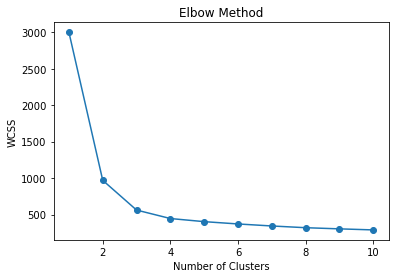

In [31]:
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


The elbow point in the graph indicates the optimal number of clusters.


In [32]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)


In [33]:
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=df.columns[:-1])
centroids


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-1.094595,-1.036122,1.114284,-0.934278,-0.813494,-1.045346
1,1.132214,1.235574,-1.106680,1.253260,1.125725,1.172991
2,-0.004449,-0.168055,-0.041370,-0.290670,-0.287579,-0.095968


Each cluster represents a group of customers with similar behavior. For example, one cluster may represent high spenders while another represents low engagement customers.


In [34]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


In [35]:
pca.explained_variance_ratio_


array([0.83560354, 0.05568764])

In [36]:
loadings = pd.DataFrame(pca.components_, columns=df.columns[:-1])
loadings


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
1,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


PC1 and PC2 capture the most important variation in the data. They combine multiple features into two dimensions.


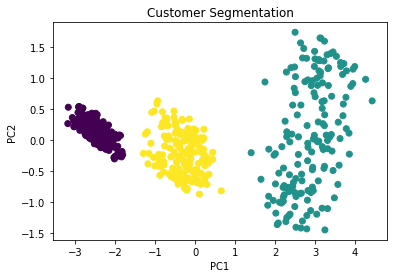

In [37]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segmentation")
plt.show()


The scatter plot shows customer clusters in reduced dimensions, making it easier to visualize segmentation.
